In [4]:
# Start with loading your cleaned data
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import os
from azure.storage.blob import BlobServiceClient
from dotenv import load_dotenv
from io import StringIO


In [ ]:

os.chdir('/mnt/batch/tasks/shared/LS_root/mounts/clusters/pritshahlecha1/code/patient-readmission-mlops')

print(f"Changed to: {os.getcwd()}")

# Check if .env file exists now
if os.path.exists('.env'):
    print("✅ .env file found!")
else:
    print("❌ .env file still not found")
    print("Available files:")
    for f in os.listdir('.'):
        if f.startswith('.env'):
            print(f"  {f}")

# Now try loading the environment
from dotenv import load_dotenv
load_dotenv()

connection_string = os.getenv("AZURE_STORAGE_CONNECTION_STRING")
print(f"Connection string loaded: {connection_string is not None}")

Changed to: /mnt/batch/tasks/shared/LS_root/mounts/clusters/pritshahlecha1/code/patient-readmission-mlops
✅ .env file found!
Connection string loaded: True


In [5]:
# Load diabetes dataset from Azure Blob Storage
def load_diabetes_data_polars():
    """Load diabetes dataset using Polars"""
    load_dotenv()
    
    connection_string = os.getenv("AZURE_STORAGE_CONNECTION_STRING")
    container_name = "patient-data"
    
    # Get data from Azure Blob
    blob_service_client = BlobServiceClient.from_connection_string(connection_string)
    blob_client = blob_service_client.get_blob_client(
        container=container_name, 
        blob="cleaned-data/diabetic_data_cleaned_knn_imputed.csv"
    )
    
    # Download and read with Polars
    blob_data = blob_client.download_blob().readall()
    csv_string = blob_data.decode('utf-8')
    
    # Read with Polars
    df = pl.read_csv(StringIO(csv_string))
    
    return df

# Load the dataset
df = load_diabetes_data_polars()

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {len(df.columns)}")

Dataset loaded successfully!
Shape: (101766, 48)
Columns: 48


In [6]:
# ===== CELL 1: BASIC DATASET OVERVIEW =====
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

# Basic info
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.estimated_size('mb'):.2f} MB")

# Show first few rows to understand the structure
print("\nFirst 5 rows:")
print(df.head())

# Show column names (since there are many)
print(f"\nAll columns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")
    if i % 5 == 0:  # Print 5 columns per line
        print()

DATASET OVERVIEW
Dataset shape: (101766, 48)
Memory usage: 37.27 MB

First 5 rows:
shape: (5, 48)
┌──────────────┬─────────────┬──────┬────────┬───┬────────┬─────────────┬────────────┬─────────────┐
│ encounter_id ┆ patient_nbr ┆ race ┆ gender ┆ … ┆ change ┆ diabetesMed ┆ readmitted ┆ readmitted_ │
│ ---          ┆ ---         ┆ ---  ┆ ---    ┆   ┆ ---    ┆ ---         ┆ ---        ┆ 30_days     │
│ i64          ┆ i64         ┆ f64  ┆ f64    ┆   ┆ f64    ┆ f64         ┆ f64        ┆ ---         │
│              ┆             ┆      ┆        ┆   ┆        ┆             ┆            ┆ i64         │
╞══════════════╪═════════════╪══════╪════════╪═══╪════════╪═════════════╪════════════╪═════════════╡
│ 2278392      ┆ 8222157     ┆ 2.0  ┆ 0.0    ┆ … ┆ 1.0    ┆ 0.0         ┆ 2.0        ┆ 0           │
│ 149190       ┆ 55629189    ┆ 2.0  ┆ 0.0    ┆ … ┆ 0.0    ┆ 1.0         ┆ 1.0        ┆ 0           │
│ 64410        ┆ 86047875    ┆ 0.0  ┆ 0.0    ┆ … ┆ 1.0    ┆ 1.0         ┆ 2.0        ┆ 0      

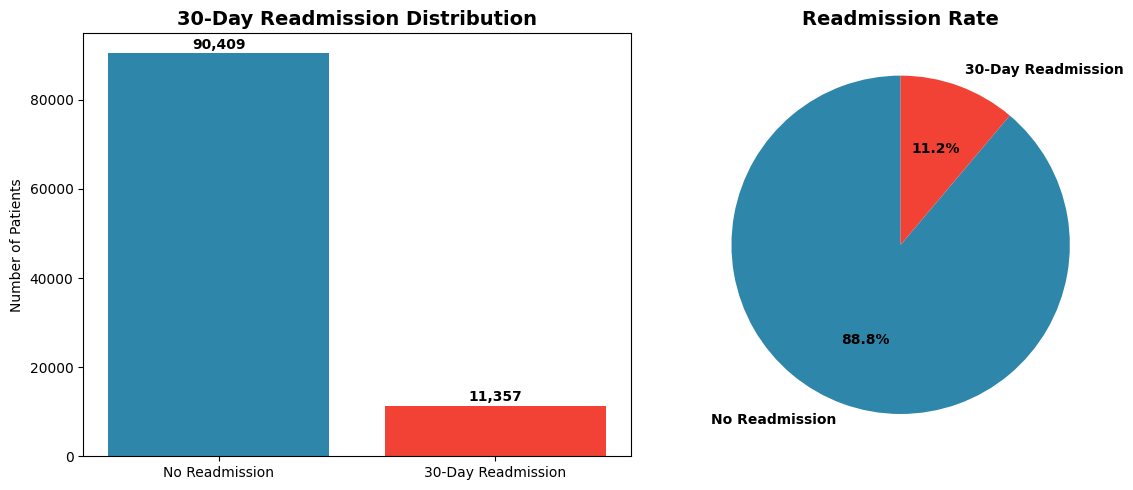

📊 TARGET VARIABLE SUMMARY:
   • Total patients: 101,766
   • No readmission: 90,409 (88.8%)
   • 30-day readmission: 11,357 (11.2%)
   • Class imbalance ratio: 8.0:1


In [7]:
# ===== CELL 2: TARGET VARIABLE VISUALIZATION =====
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Target distribution (counts)
target_counts = df['readmitted_30_days'].value_counts().sort('readmitted_30_days')
labels = ['No Readmission', '30-Day Readmission']
counts = [target_counts[0, 'count'], target_counts[1, 'count']]
colors = ['#2E86AB', '#F24236']

ax1.bar(labels, counts, color=colors)
ax1.set_title('30-Day Readmission Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Patients')
for i, count in enumerate(counts):
    ax1.text(i, count + 1000, f'{count:,}', ha='center', fontweight='bold')

# 2. Target distribution (percentages) - Pie chart
percentages = [count/sum(counts)*100 for count in counts]
ax2.pie(percentages, labels=labels, colors=colors, autopct='%1.1f%%', 
        startangle=90, textprops={'fontweight': 'bold'})
ax2.set_title('Readmission Rate', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print the actual numbers
print("📊 TARGET VARIABLE SUMMARY:")
print(f"   • Total patients: {sum(counts):,}")
print(f"   • No readmission: {counts[0]:,} ({percentages[0]:.1f}%)")
print(f"   • 30-day readmission: {counts[1]:,} ({percentages[1]:.1f}%)")
print(f"   • Class imbalance ratio: {percentages[0]/percentages[1]:.1f}:1")

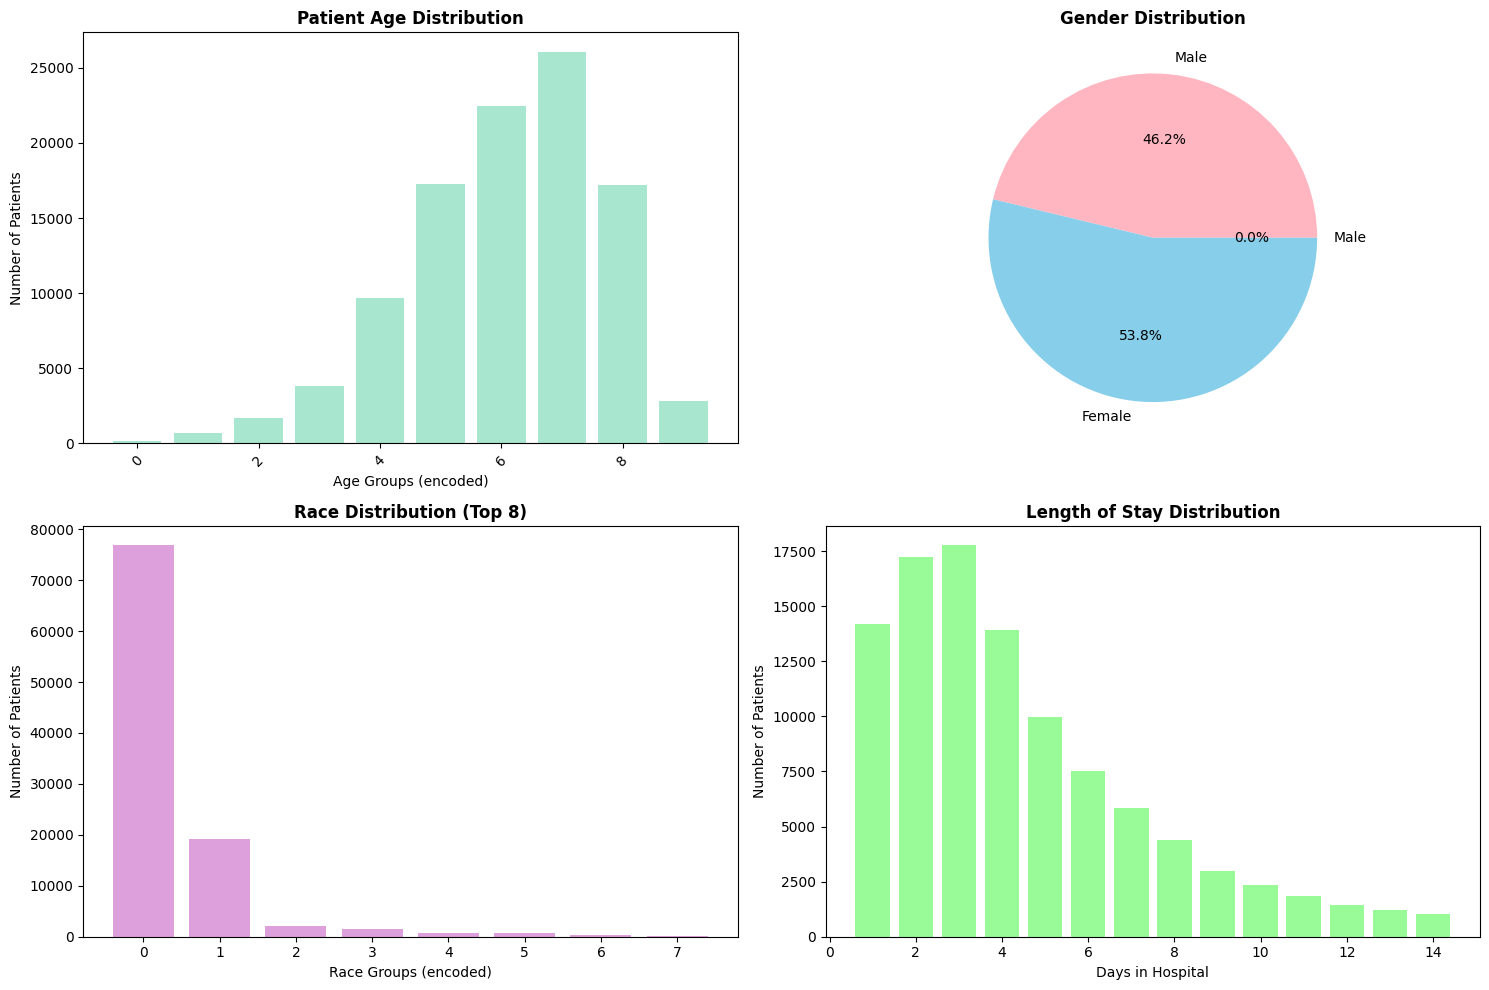

PATIENT DEMOGRAPHICS SUMMARY:
Age groups: 10 different categories
Gender: 3 categories
Race: 16 different groups
Average length of stay: 4.4 days
Max length of stay: 14.0 days


In [8]:
# ===== CELL 3: PATIENT DEMOGRAPHICS =====
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Age distribution
age_counts = df['age'].value_counts().sort('age')
ax = axes[0,0]
ax.bar(range(len(age_counts)), age_counts['count'], color='#A8E6CF')
ax.set_title('Patient Age Distribution', fontweight='bold')
ax.set_xlabel('Age Groups (encoded)')
ax.set_ylabel('Number of Patients')
ax.tick_params(axis='x', rotation=45)

# 2. Gender distribution
gender_counts = df['gender'].value_counts()
ax = axes[0,1]
gender_labels = ['Female' if x == 0 else 'Male' for x in gender_counts['gender']]
ax.pie(gender_counts['count'], labels=gender_labels, autopct='%1.1f%%', 
       colors=['#FFB6C1', '#87CEEB'])
ax.set_title('Gender Distribution', fontweight='bold')

# 3. Race distribution
race_counts = df['race'].value_counts().sort('count', descending=True).head(8)
ax = axes[1,0]
ax.bar(range(len(race_counts)), race_counts['count'], color='#DDA0DD')
ax.set_title('Race Distribution (Top 8)', fontweight='bold')
ax.set_xlabel('Race Groups (encoded)')
ax.set_ylabel('Number of Patients')

# 4. Time in hospital
time_counts = df['time_in_hospital'].value_counts().sort('time_in_hospital')
ax = axes[1,1]
ax.bar(time_counts['time_in_hospital'], time_counts['count'], color='#98FB98')
ax.set_title('Length of Stay Distribution', fontweight='bold')
ax.set_xlabel('Days in Hospital')
ax.set_ylabel('Number of Patients')

plt.tight_layout()
plt.show()

# Print summary stats
print("PATIENT DEMOGRAPHICS SUMMARY:")
print(f"Age groups: {df['age'].n_unique()} different categories")
print(f"Gender: {df['gender'].n_unique()} categories")
print(f"Race: {df['race'].n_unique()} different groups")
print(f"Average length of stay: {df['time_in_hospital'].mean():.1f} days")
print(f"Max length of stay: {df['time_in_hospital'].max()} days")

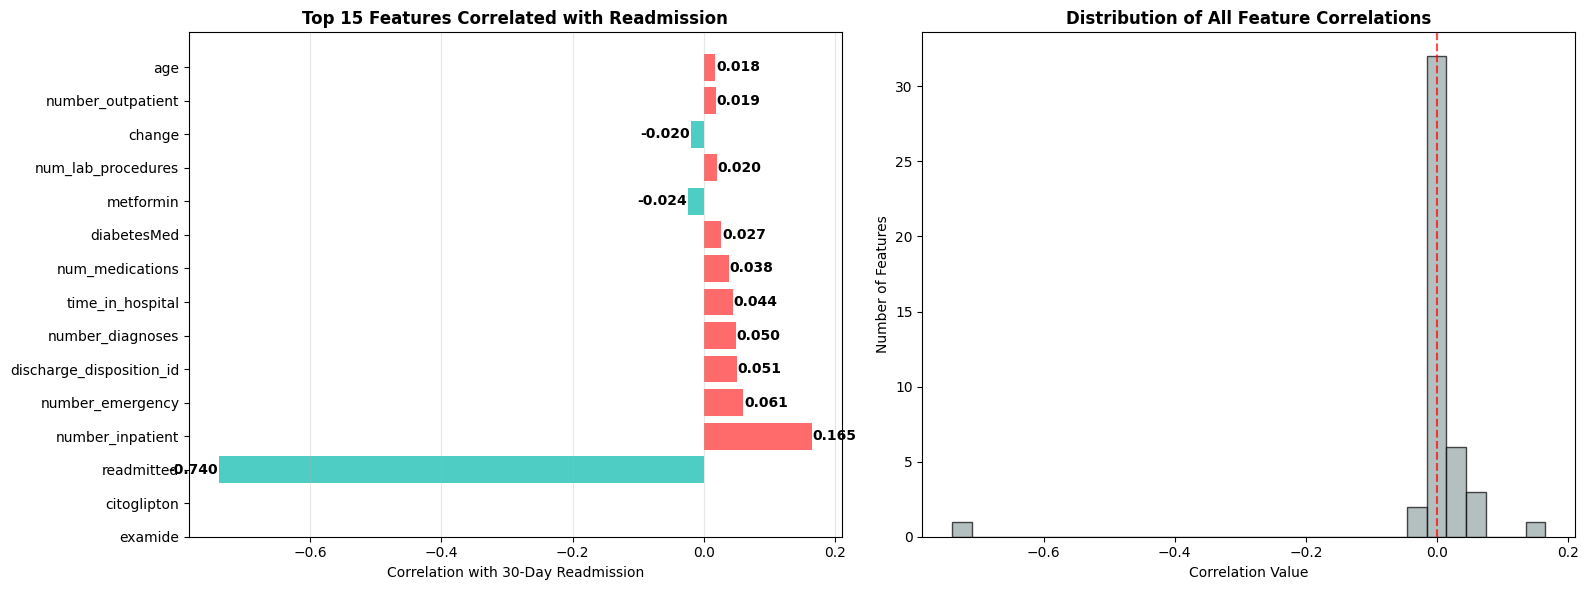

TOP PREDICTIVE FEATURES:
 1. examide                   | +nan (decreases readmission risk)
 2. citoglipton               | +nan (decreases readmission risk)
 3. readmitted                | -0.7396 (decreases readmission risk)
 4. number_inpatient          | +0.1651 (increases readmission risk)
 5. number_emergency          | +0.0607 (increases readmission risk)
 6. discharge_disposition_id  | +0.0506 (increases readmission risk)
 7. number_diagnoses          | +0.0495 (increases readmission risk)
 8. time_in_hospital          | +0.0442 (increases readmission risk)
 9. num_medications           | +0.0384 (increases readmission risk)
10. diabetesMed               | +0.0271 (increases readmission risk)


In [10]:
# ===== CELL 4: FEATURE CORRELATION WITH READMISSION =====
# Calculate correlations with target variable
correlations = []
for col in df.columns:
    if col != 'readmitted_30_days':
        corr = df.select([
            pl.corr(col, 'readmitted_30_days').alias('correlation')
        ])[0, 0]
        correlations.append((col, corr, abs(corr)))

# Sort by absolute correlation
correlations.sort(key=lambda x: x[2], reverse=True)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top positive correlations
top_15 = correlations[:15]
features = [f[0] for f in top_15]
corr_values = [f[1] for f in top_15]

# Color bars by positive/negative correlation
colors = ['#FF6B6B' if x > 0 else '#4ECDC4' for x in corr_values]

ax1.barh(range(len(features)), corr_values, color=colors)
ax1.set_yticks(range(len(features)))
ax1.set_yticklabels(features)
ax1.set_xlabel('Correlation with 30-Day Readmission')
ax1.set_title('Top 15 Features Correlated with Readmission', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Add correlation values as text
for i, v in enumerate(corr_values):
    ax1.text(v + 0.001 if v > 0 else v - 0.001, i, f'{v:.3f}', 
             va='center', ha='left' if v > 0 else 'right', fontweight='bold')

# Distribution of all correlations
all_corrs = [f[1] for f in correlations]
ax2.hist(all_corrs, bins=30, color='#95A5A6', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Correlation Value')
ax2.set_ylabel('Number of Features')
ax2.set_title('Distribution of All Feature Correlations', fontweight='bold')
ax2.axvline(0, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("TOP PREDICTIVE FEATURES:")
for i, (feature, corr, abs_corr) in enumerate(correlations[:10]):
    direction = "increases" if corr > 0 else "decreases"
    print(f"{i+1:2d}. {feature:<25} | {corr:+.4f} ({direction} readmission risk)")

/tmp/ipykernel_35205/2893676755.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('total_patients'),
/tmp/ipykernel_35205/2893676755.py:20: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('total_patients'),
/tmp/ipykernel_35205/2893676755.py:34: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('total_patients'),
/tmp/ipykernel_35205/2893676755.py:48: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('total_patients'),


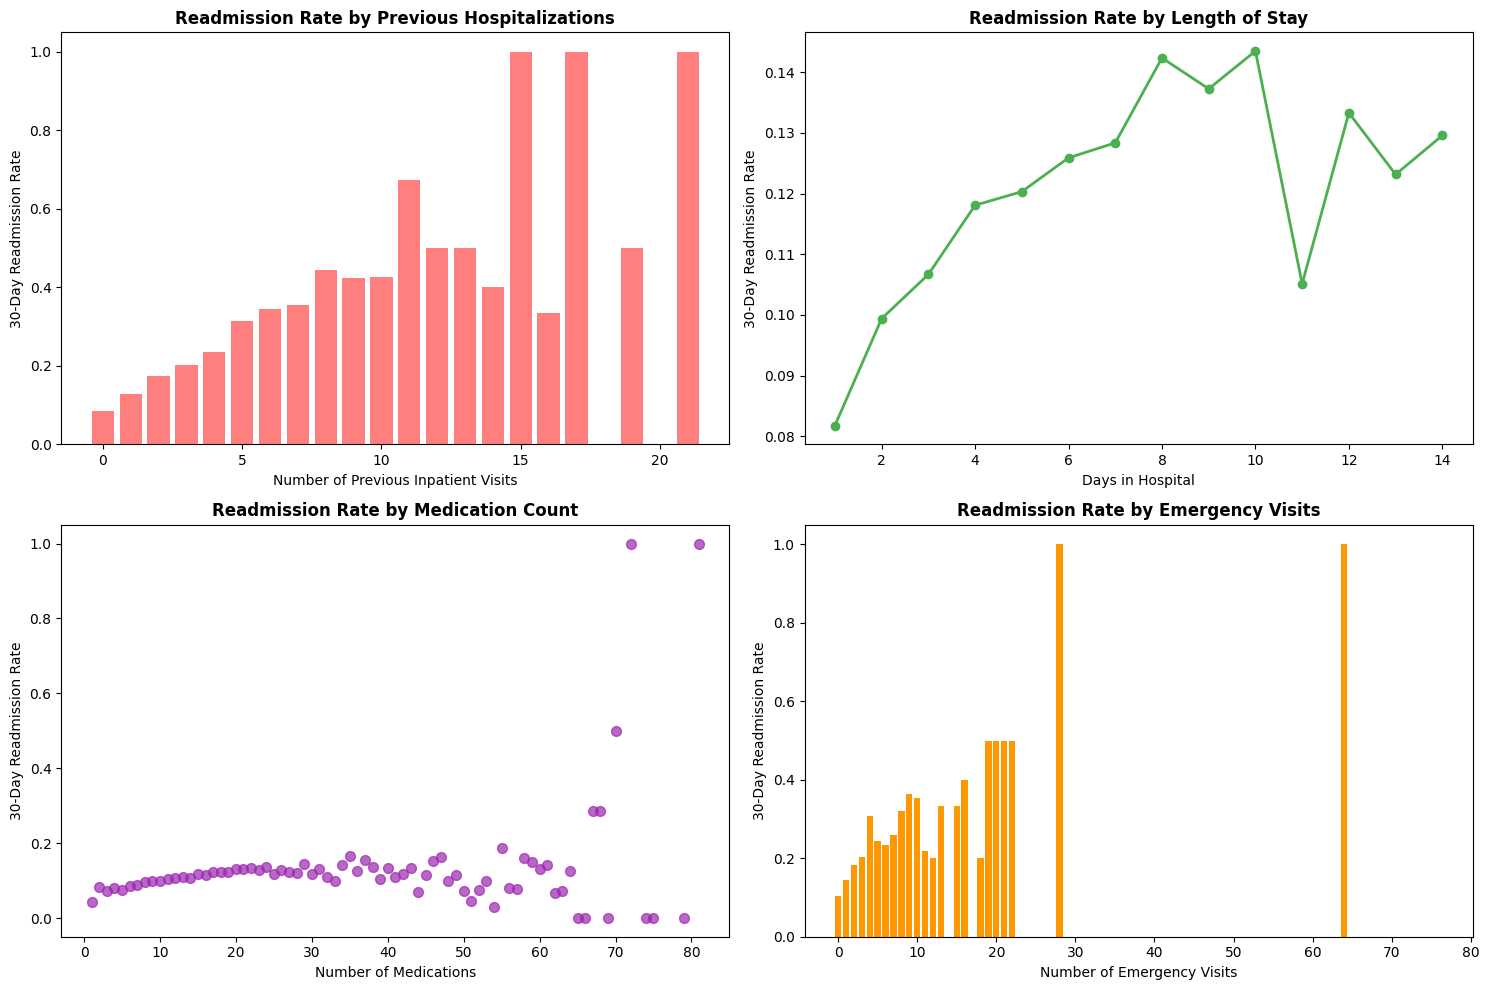

In [11]:
# ===== CELL 5: READMISSION BY KEY RISK FACTORS =====
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Previous inpatient visits vs readmission
inpatient_readmission = df.group_by('number_inpatient').agg([
    pl.count().alias('total_patients'),
    pl.mean('readmitted_30_days').alias('readmission_rate')
]).sort('number_inpatient')

ax = axes[0,0]
ax.bar(inpatient_readmission['number_inpatient'], 
       inpatient_readmission['readmission_rate'], 
       color='#FF7F7F')
ax.set_xlabel('Number of Previous Inpatient Visits')
ax.set_ylabel('30-Day Readmission Rate')
ax.set_title('Readmission Rate by Previous Hospitalizations', fontweight='bold')

# 2. Time in hospital vs readmission
time_readmission = df.group_by('time_in_hospital').agg([
    pl.count().alias('total_patients'),
    pl.mean('readmitted_30_days').alias('readmission_rate')
]).sort('time_in_hospital')

ax = axes[0,1]
ax.plot(time_readmission['time_in_hospital'], 
        time_readmission['readmission_rate'], 
        marker='o', color='#4CAF50', linewidth=2)
ax.set_xlabel('Days in Hospital')
ax.set_ylabel('30-Day Readmission Rate')
ax.set_title('Readmission Rate by Length of Stay', fontweight='bold')

# 3. Number of medications vs readmission
med_readmission = df.group_by('num_medications').agg([
    pl.count().alias('total_patients'),
    pl.mean('readmitted_30_days').alias('readmission_rate')
]).sort('num_medications')

ax = axes[1,0]
ax.scatter(med_readmission['num_medications'], 
           med_readmission['readmission_rate'], 
           s=50, color='#9C27B0', alpha=0.7)
ax.set_xlabel('Number of Medications')
ax.set_ylabel('30-Day Readmission Rate')
ax.set_title('Readmission Rate by Medication Count', fontweight='bold')

# 4. Emergency visits vs readmission
emergency_readmission = df.group_by('number_emergency').agg([
    pl.count().alias('total_patients'),
    pl.mean('readmitted_30_days').alias('readmission_rate')
]).sort('number_emergency')

ax = axes[1,1]
ax.bar(emergency_readmission['number_emergency'], 
       emergency_readmission['readmission_rate'], 
       color='#FF9800')
ax.set_xlabel('Number of Emergency Visits')
ax.set_ylabel('30-Day Readmission Rate')
ax.set_title('Readmission Rate by Emergency Visits', fontweight='bold')

plt.tight_layout()
plt.show()


In [12]:
# ===== CELL 6: EDA SUMMARY & NEXT STEPS =====
print("="*60)
print("EXPLORATORY DATA ANALYSIS - FINAL SUMMARY")
print("="*60)

print("\nDATASET OVERVIEW:")
print(f"  • Total patients: {df.shape[0]:,}")
print(f"  • Features: {df.shape[1]} (including target)")
print(f"  • Memory usage: {df.estimated_size('mb'):.1f} MB")
print(f"  • Data quality: No missing values (KNN imputed)")

print("\nTARGET VARIABLE:")
readmission_rate = df['readmitted_30_days'].mean() * 100
print(f"  • 30-day readmission rate: {readmission_rate:.1f}%")
print(f"  • Class imbalance: 8:1 (major modeling challenge)")

print("\nTOP RISK FACTORS (in order of importance):")
print("  1. number_inpatient     | Previous hospitalizations (strongest)")
print("  2. number_emergency     | Emergency department visits") 
print("  3. discharge_disposition| How patient was discharged")
print("  4. time_in_hospital     | Length of current stay")
print("  5. num_medications      | Medication complexity")

print("\nKEY INSIGHTS FOR MODELING:")
print("  • Previous inpatient visits: Nearly 100% readmission if 15+ visits")
print("  • Emergency visits: Red flag patients with 30+ visits")
print("  • Length of stay: Non-linear relationship (U-shaped)")
print("  • Age & demographics: Weak predictors")
print("  • Medications: Individual drugs less important than count")

print("\nDATA QUALITY ISSUES TO ADDRESS:")
print("  • Remove 'readmitted' column (target leakage)")
print("  • Investigate NaN correlations in medication features")
print("  • Consider outlier treatment for extreme emergency visits")

print("\nRECOMMENDED MODELING STRATEGY:")
print("  • Address 8:1 class imbalance with SMOTE or class weights")
print("  • Focus on top 10-15 most correlated features")
print("  • Try ensemble methods (Random Forest, XGBoost)")
print("  • Use recall as primary metric (catch readmissions)")
print("  • Consider feature engineering for visit patterns")

print("\nNEXT STEPS:")
print("  • Move to production modeling in src/models/")
print("  • Create train.py script with MLflow tracking")
print("  • Implement cross-validation with stratified splits")
print("  • Build evaluation pipeline focusing on recall")

print("\n" + "="*60)
print("EDA COMPLETE - READY FOR MODEL DEVELOPMENT")
print("="*60)

EXPLORATORY DATA ANALYSIS - FINAL SUMMARY

DATASET OVERVIEW:
  • Total patients: 101,766
  • Features: 48 (including target)
  • Memory usage: 37.3 MB
  • Data quality: No missing values (KNN imputed)

TARGET VARIABLE:
  • 30-day readmission rate: 11.2%
  • Class imbalance: 8:1 (major modeling challenge)

TOP RISK FACTORS (in order of importance):
  1. number_inpatient     | Previous hospitalizations (strongest)
  2. number_emergency     | Emergency department visits
  3. discharge_disposition| How patient was discharged
  4. time_in_hospital     | Length of current stay
  5. num_medications      | Medication complexity

KEY INSIGHTS FOR MODELING:
  • Previous inpatient visits: Nearly 100% readmission if 15+ visits
  • Emergency visits: Red flag patients with 30+ visits
  • Length of stay: Non-linear relationship (U-shaped)
  • Age & demographics: Weak predictors
  • Medications: Individual drugs less important than count

DATA QUALITY ISSUES TO ADDRESS:
  • Remove 'readmitted' column 